In [8]:
"""
TASK 1: Day-ahead QP Objective Modification
============================================================
What this notebook is for: this is the master notebook for the Day-ahead
Batch QP BESS scheduling problem. It defines every helper function reused
by Tasks 1, 2, 3, and 4, then runs the QP once under PERFECT forecast data
to produce the Task 1 reference schedule.

What you need to do in this notebook:
  - Complete the @TODO objective function inside solve_daily_qp() below.
  - Everything else (data loading, the batch loop, plotting) is already
    implemented -- you do not need to modify it, only run it.

Before you run this notebook: upload perfect_load.csv and perfect_pv.csv
to the Colab file panel (folder icon on the left-hand side).
"""

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# SECTION: Data loading helpers
# (No changes needed -- these are complete and reused by every task notebook.)
# ==============================================================================
def read_load_generation(load_file, pv_file):
    """
    Read load and generation from CSV files
    """
    df_load = pd.read_csv(load_file)
    df_pv = pd.read_csv(pv_file)

    dates = df_load.iloc[:, 0].astype(str).tolist()

    load_profiles = df_load.iloc[:, 1:].values.flatten()
    pv_profiles = df_pv.iloc[:, 1:].values.flatten()
    days = len(df_load)

    return load_profiles, pv_profiles, days, dates


def generate_eta_profiles(days, steps_per_day):
    """
    Generates the daily time-of-use tariff and copies it
    across the entire multi-day horizon.
    """
    eta_day = np.zeros(steps_per_day)
    eta_day[np.r_[0:14, 44:48]] = 0.03   # Off-peak rate ($/kWh)
    eta_day[np.r_[14:28, 40:44]] = 0.06  # Shoulder rate ($/kWh)
    eta_day[28:40]               = 0.30  # Peak rate ($/kWh)

    eta_profiles = np.tile(eta_day, days)
    return eta_profiles

# ==============================================================================
# SECTION: Core QP solver
# @TODO: you must complete the objective function below -- see Task 1,
# Step 4 of the assessment instructions. Do NOT modify the constraints;
# they are already correctly implemented.
# ==============================================================================
def solve_daily_qp(p_load_day, p_pv_day, eta_day, z_init, steps_per_day, delta, p_min, p_max, c_max, w):
    """
    Solves the single-day Batch QP subproblem for one 24-hour window, given
    the previous day's ending SOC z_init as this day's starting SOC.
    Returns the optimal BESS power x1(k), grid power x2(k), and SOC z(k)
    trajectories for this single day.
    """
    x1 = cp.Variable(steps_per_day)  # BESS power (positive=discharge, negative=charge)
    x2 = cp.Variable(steps_per_day)  # Grid power (positive=import, negative=export)
    z  = cp.Variable(steps_per_day + 1)  # BESS SOC


    # =========================================================================
    # @TODO [Task 1]: Modify the objective function:
    #                min sum [ -delta * eta(k) * x1(k) + w * eta(k) * (x2(k))^2 ]
    #
    # Note: Use @ operator for dot product,
    #           cp.multiply(...) for element-wise multiplication,
    #           cp.sum(...) for summation.
    # =========================================================================

    objective = cp.Minimize(-delta * (eta_day @ x1)+ w * cp.sum(cp.multiply(eta_day, cp.square(x2)))

)



    # QP constraints -- already implemented, do not modify.
    # =========================================================================
    # SOC dynamics -- why the code indexing differs from the LaTeX
    # -------------------------------------------------------------------------
    # LaTeX (initial SoC z(0), interval index k = 1..s):
    #     z(k) = z(k-1) - delta * x1(k),        z(s) = z(0)      [Eqs. 15c, 15f]
    #
    # The code arrays are 0-based, and z carries ONE extra slot for z(0):
    #     z[0 .. s]     <->  z(0), z(1), ..., z(s)    (length s+1;  z[0] = z(0))
    #     x1[0 .. s-1]  <->  x1(1), x1(2), ..., x1(s) (length s;  there is no x1(0))
    #   =>  z[k] = z(k)   but   x1[k] = x1(k+1)
    #
    # Re-indexing the LaTeX recurrence to these 0-based arrays gives:
    #     z[k+1] = z[k] - delta * x1[k],        k = 0 .. s-1
    # It is the SAME equation -- the loop is just shifted so x1's index lines up
    # with k, which is why the range starts at 0 (not 1) and there is no x1[k-1].
    # =========================================================================
    constraints = [
        x2 == p_load_day - p_pv_day - x1,       # Power balance
        x1 >= p_min, x1 <= p_max,               # BESS power limits
        z >= 0.0, z <= c_max,                    # BESS capacity boundaries
        z[0] == z_init                          # z[0] = z(0): initial SoC (see indexing note above)
    ]

    # SOC dynamics (0-based, loop-shifted -- see note above)
    # k loops from 0...47
    for k in range(steps_per_day):            # k = 0..s-1 (0-based; see note above)
        constraints += [z[k+1] == z[k] - delta * x1[k]]

    # Daily periodic terminal constraint
    constraints += [z[steps_per_day] == z[0]]   # cyclic: z(s) = z(0)

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    if prob.status != cp.OPTIMAL:
        print(f"Warning: Daily subproblem optimization returned status: {prob.status}")
    # Exclude z[0], the fixed initial-energy boundary, so the returned
    # energy trajectory has one end-of-interval value per dispatch step.
    return x1.value, x2.value, z.value[1:]


# ==============================================================================
# SECTION: Multi-day batch loop
# (No changes needed -- calls solve_daily_qp() once per day and stitches the
#  daily results into full-horizon arrays, inheriting SOC across day boundaries.)
# ==============================================================================
def run_batch_loop(global_z_init, days, steps_per_day, total_horizon, delta, load_profiles, pv_profiles, eta_profiles, p_min, p_max, c_max, w):
    """
    Executes the multi-day batch loop and stitches isolated daily optimization cycles together.
    """
    all_x1_BESS = np.zeros(total_horizon)
    all_x2_grid = np.zeros(total_horizon)
    all_z_SOC   = np.zeros(total_horizon)

    current_z_init = global_z_init

    for d in range(days):
        start_idx = d * steps_per_day
        end_idx   = (d + 1) * steps_per_day

        # Extract 48-step horizons for the current batch cycle
        p_load_day = load_profiles[start_idx:end_idx]
        p_pv_day   = pv_profiles[start_idx:end_idx]
        eta_day    = eta_profiles[start_idx:end_idx]

        # Run QP for a single day
        x1_opt, x2_opt, z_opt = solve_daily_qp(
            p_load_day, p_pv_day, eta_day, current_z_init,
            steps_per_day, delta, p_min, p_max, c_max, w
        )

        # Stitch decision array results into global outputs
        all_x1_BESS[start_idx:end_idx] = x1_opt
        all_x2_grid[start_idx:end_idx] = x2_opt
        all_z_SOC[start_idx:end_idx]   = z_opt

        # State inheritance
        current_z_init = z_opt[-1]

    print("Batch QP Completed.")
    return all_x1_BESS, all_x2_grid, all_z_SOC


# ==============================================================================
# SECTION: Visualization
# (No changes needed -- produces the tariff, load/PV, BESS+grid power, and SOC
#  plots you will present for Task 1, Step 5.)
# ==============================================================================
def plot_results(timeline_hours, load_profiles, pv_profiles, eta_profiles, all_x1_BESS, all_x2_grid, all_z_SOC, p_max, c_max, days, delta, dates):
    """
    Visualization
    """
    # Plot configurations
    plt.rcParams.update({
        'font.size': 13,
        'axes.labelsize': 14,
        'axes.titlesize': 15,
        'savefig.dpi': 300
    })

    # Generate timeline ticks (every 6 hours)
    total_hours = timeline_hours[-1] + delta
    tick_hours = np.arange(0, total_hours + 1, 6)

    time_labels = []
    for h in tick_hours:
        day_idx = int(h // 24)
        time_str = f"{int(h % 24):02d}:30"

        if h % 24 == 0 and day_idx < days:
            time_labels.append(f"{dates[day_idx]}\n{time_str}")
        else:
            time_labels.append(f"\n{time_str}")

    max_power_val = max(load_profiles.max(), pv_profiles.max(), all_x2_grid.max())
    min_power_val = min(load_profiles.min(), pv_profiles.min(), all_x2_grid.min(), -p_max)

    # ---- Figure 1: Electricity Tariff Profile ----
    plt.figure(figsize=(14, 4))
    plt.plot(timeline_hours, eta_profiles, color='crimson', linestyle='-', linewidth=2.5,
             drawstyle='steps-post', label='Electricity Tariff ($/kWh)')

    for d in range(1, days):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=2.5, label='Day Boundary')

    plt.title('Time-of-Use Electricity Tariff', y=1.05)
    plt.xlabel('Time Horizon')
    plt.ylabel('Tariff Rate ($/kWh)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

    # ---- Figure 2: Load and Generation Profiles ----
    plt.figure(figsize=(14, 5))
    plt.plot(timeline_hours, load_profiles, color='black', linestyle='--', linewidth=2.0,
             drawstyle='steps-post', label='Residential Load (kW)')
    plt.plot(timeline_hours, pv_profiles, color='orange', linestyle='-', linewidth=2.0,
             drawstyle='steps-post', label='Solar PV Generation (kW)')

    for d in range(1, days):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=2.5, label='Day Boundary')

    plt.title('Load and Generation Profiles', y=1.05)
    plt.xlabel('Time horizon')
    plt.ylabel('Active Power (kW)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

    # ---- Figure 3: Optimal Battery and Grid Power ----
    plt.figure(figsize=(14, 5))
    plt.plot(timeline_hours, all_x2_grid, color='blue', linestyle='-', linewidth=2.5,
             drawstyle='steps-post', label='Optimal Grid Power $x_2$ (kW)')
    plt.plot(timeline_hours, all_x1_BESS, color='green', linestyle='-.', linewidth=2.0,
             drawstyle='steps-post', label='Optimal BESS Power $x_1$ (kW)')

    for d in range(1, days):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=2.5, label='Day Boundary')

    plt.title('Optimal Battery and Grid Power Under Batch QP', y=1.05)
    plt.xlabel('Time Horizon')
    plt.ylabel('Active Power (kW)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

    # ---- Figure 4: BESS SOC ----
    plt.figure(figsize=(14, 5))
    plt.plot(timeline_hours, all_z_SOC, color='purple', linestyle='-', linewidth=3.0,
             drawstyle='steps-post', label='BESS SOC $z$ (kWh)')

    for d in range(1, days):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=2.5, label='Day Boundary')

    plt.title('Battery SOC under Batch QP', y=1.05)
    plt.xlabel('Time Horizon')
    plt.ylabel('Battery SOC (kWh)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()


Batch QP Completed.


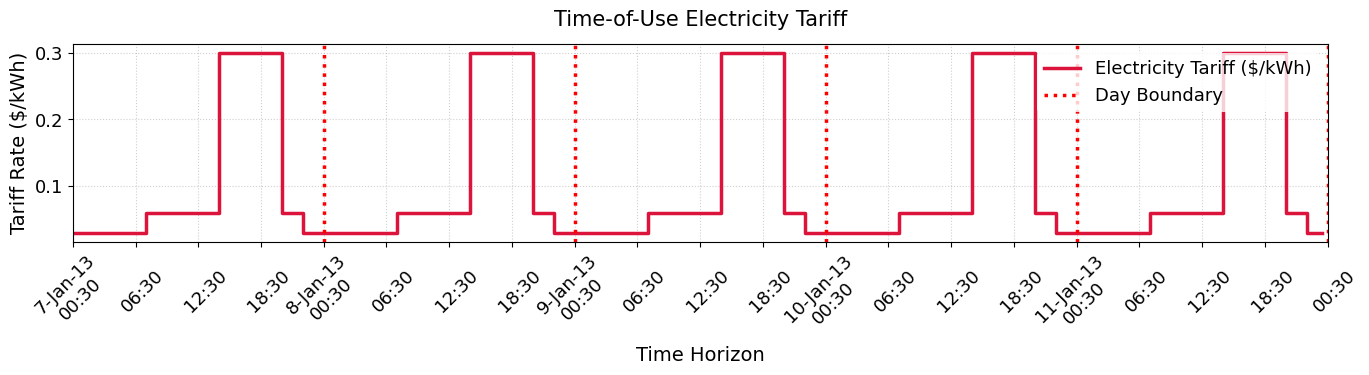

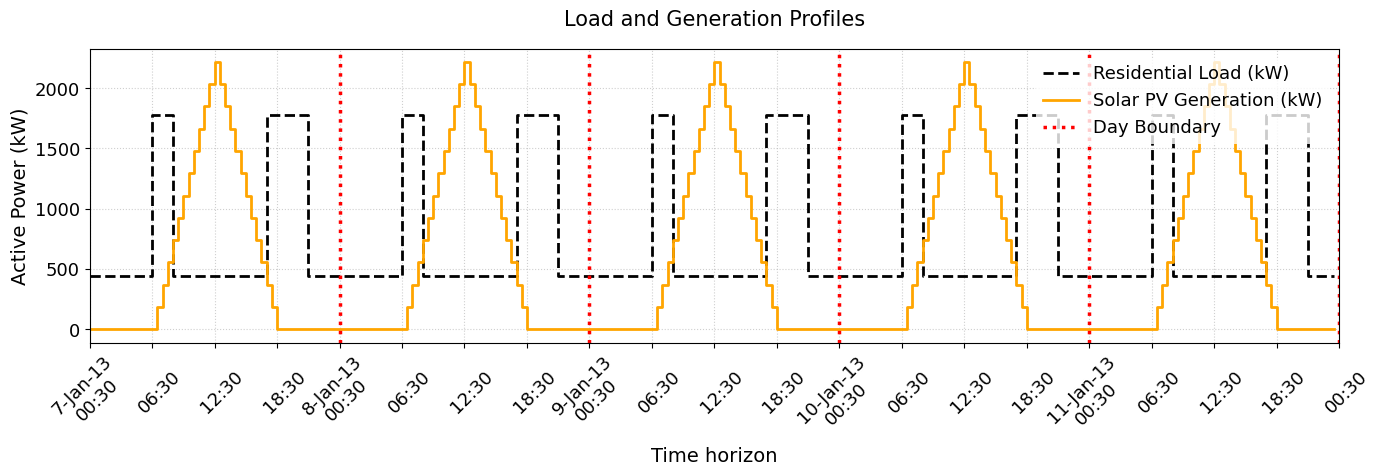

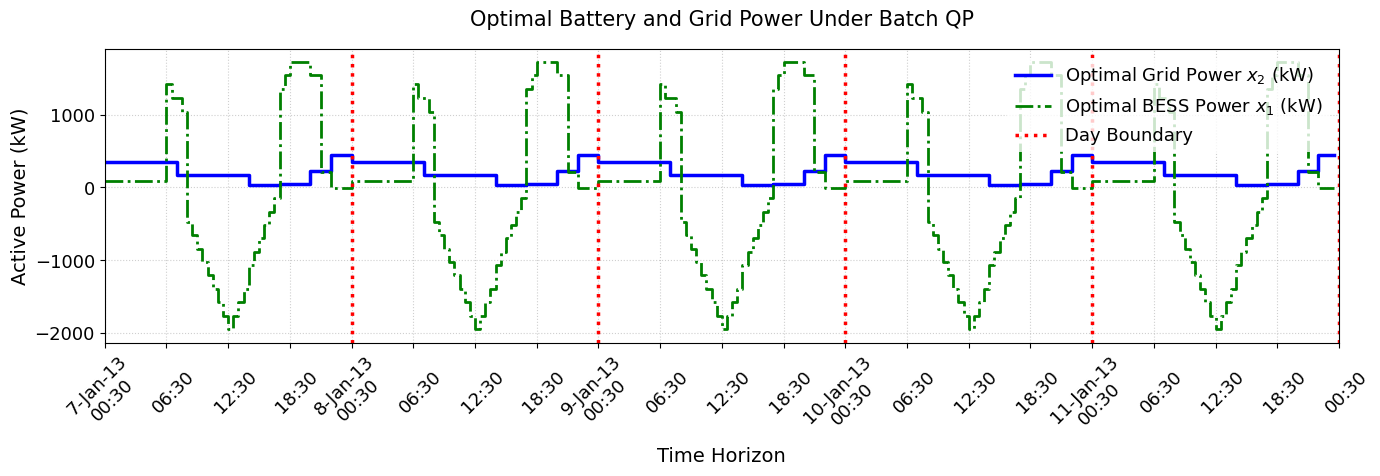

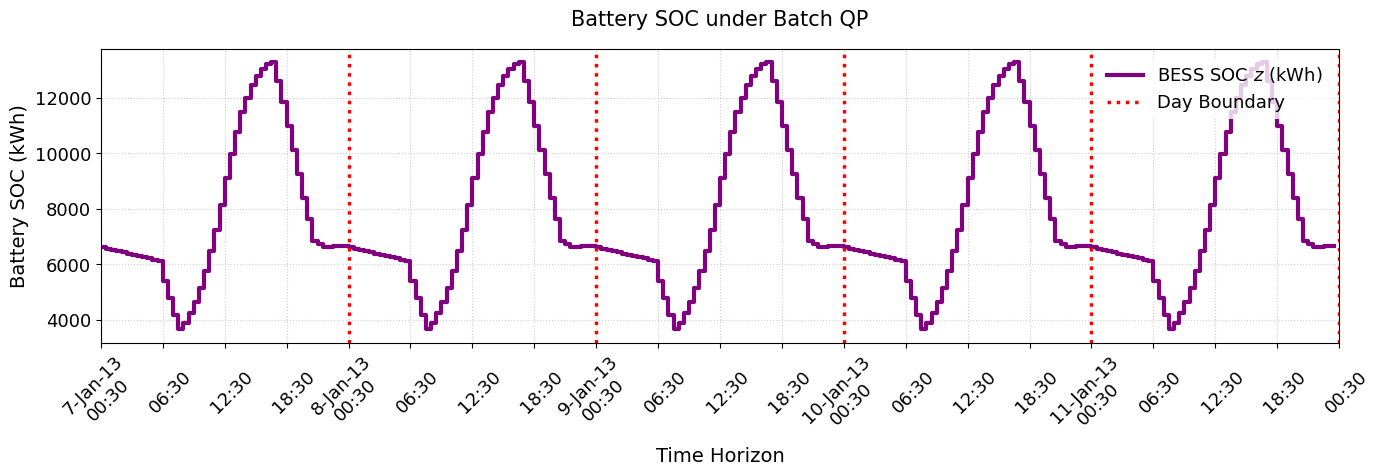

In [9]:
"""
MAIN EXECUTION
============================================================
Runs the completed solve_daily_qp() across the full multi-day horizon using
PERFECT load/PV data, then plots the results and saves
optimal_BESS_perfect.csv (needed for Task 2). Just run this cell after
completing the TODO above -- no changes needed here.
"""

# Configuration parameters
steps_per_day = 48
delta = 0.5   # Corresponds to DELTA_HOURS

### ---- Read load and generation data (perfect forecast, for Task 1) ----
### For Task 2, comment these three lines out and uncomment the synthetic-data
### lines below instead -- see Task 2, Step 2 of the assessment instructions.
filename = 'optimal_BESS_perfect.csv'
load_csv_path = 'perfect_load.csv'
pv_csv_path = 'perfect_pv.csv'

filename = 'optimal_BESS_synthetic.csv'
load_csv_path = 'synthetic_load.csv'
pv_csv_path = 'synthetic_pv.csv'

load_profiles, pv_profiles, days, dates = read_load_generation(load_csv_path, pv_csv_path)

total_horizon = days * steps_per_day

# Generate the multi-day tariff profile
eta_profiles = generate_eta_profiles(days, steps_per_day)

### ---- BESS (battery) parameters -- fixed for Task 1, do not change here ----
total_customers = 1330
p_min = -5.0 * total_customers     # Maximum charging power
p_max = 5.0 * total_customers      # Maximum discharging power
c_max = 10.0 * total_customers     # Battery capacity
z_init = 5.0 * total_customers     # Initial 50% SOC level

time_indices_total = np.arange(total_horizon)
timeline_hours = time_indices_total * delta

# Objective weight w (see the QP objective TODO above)
w = 1

### ---- Solve the QP across the full horizon ----
all_x1_BESS, all_x2_grid, all_z_SOC = run_batch_loop(
    z_init, days, steps_per_day, total_horizon, delta,
    load_profiles, pv_profiles, eta_profiles, p_min, p_max, c_max, w
)

### ---- Visualizations (Task 1, Step 5) ----
plot_results(
    timeline_hours, load_profiles, pv_profiles, eta_profiles,
    all_x1_BESS, all_x2_grid, all_z_SOC, p_max, c_max, days, delta, dates
)

### ---- Save the optimal BESS trajectory to CSV ----
### You will need this file (renamed per the `filename` variable above) for
### Task 2 -- download it from the Colab file panel once this cell has run.
steps = np.arange(len(all_x1_BESS))
df = pd.DataFrame({
    'Time_Step': steps,
    'BESS_Power_x1_kW': all_x1_BESS
})
df.to_csv(filename, index=False)
